## Feature-Übersicht

| Feature                  | Gruppe    | Begründung                                                                                                                                         |
|--------------------------|-----------|----------------------------------------------------------------------------------------------------------------------------------------------------|
| `ghi_cloudy_sky`         | Strahlung | Globalstrahlung unter Realbedingungen — wichtigster PV-Treiber                                                                                     |
| `clear_sky_index`        | Strahlung | GHI / GHI_clear ∈ [0, 1.5] — normiert Strahlung auf Klarhimmelwert; macht den Bewölkungsgrad über Tageszeiten und Jahreszeiten hinweg vergleichbar |
| `temperature_2m`         | Wetter    | Hohe Temperatur senkt Modulwirkungsgrad (~−0,4 %/K) ab 25 °C                                                                                       |
| `cloud_cover_low`        | Wetter    | Niedrige Wolken blockieren Direktstrahlung am stärksten; als NWP-Vorhersage 24 h im Voraus verfügbar                                               |
| `hour_cos_shifted`       | Zeit      | Phasenverschobener Kosinus der Tagesstunde — Maximum bei Sonnenmittag (h★ ≈ 12)                                                                    |
| `month_cos_shifted`      | Zeit      | Phasenverschobener Kosinus des Monats — Maximum im produktionsstärksten Monat (m★ ≈ Juni)                                                          |
| `Solarproduktion_lag_96` | Lag       | Produktion von exakt 24 h zuvor (96 × 15 min) — hohe Autokorrelation; frühester im Day-Ahead-Setting verfügbarer Lag                               |

Dieses Notebook leitet `hour_cos_shifted` und `month_cos_shifted` her und begründet die Wahl
der Phasenverschiebung gegenüber der Standard-Sinus/Kosinus-Kodierung.

# Zeitmerkmale — Zyklische Kodierung mit Phasenverschiebung

**Ziel:** Robuste zyklische Zeitmerkmale für die PV-Produktionsprognose ableiten und
die phasenverschobene Kosinusfunktion als beste Einzelmerkmal-Kodierung begründen.

## Warum zyklische Kodierung?

Rohe numerische Zeitwerte erzeugen eine künstliche Diskontinuität: Stunde 23 und
Stunde 0 sind in der Realität benachbart, aber als Ganzzahlen 23 Einheiten voneinander
entfernt. Die Projektion auf den Einheitskreis beseitigt dieses Problem:

$$h_\text{sin} = \sin\!\left(\frac{2\pi h}{24}\right), \quad h_\text{cos} = \cos\!\left(\frac{2\pi h}{24}\right)$$

## Warum eine Phasenverschiebung?

Die Standard-Kosinuskodierung hat ihr Maximum (`cos = 1`) bei **Stunde 0** (Mitternacht) —
dem Zeitpunkt der *niedrigsten* PV-Produktion. Ein **phasenverschobener Kosinus** dreht
die Kodierung so, dass das Maximum mit dem empirischen Produktionshöchstwert übereinstimmt
(Sonnenmittag ≈ 12:00 Uhr bzw. Sommermonat ≈ Juli):

$$x_\text{cos}^\star = \cos\!\left(\frac{2\pi (x - x^\star)}{T}\right), \quad x^\star = \arg\max_x \tilde{y}(x)$$

Das ergibt ein einzelnes Merkmal, das die „Nähe zum Produktionsmaximum" direkt mit
maximaler linearer Korrelation zur Zielvariable kodiert.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.data.preprocessing import load_processed_data

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

TARGET = "Solarproduktion"

df = load_processed_data(split="all")
df["hour"]  = df["timestamp"].dt.hour
df["month"] = df["timestamp"].dt.month

print(f"Shape: {df.shape}")
print(f"Zeitraum: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Tageslichtstunden (Produktion > 0): {(df[TARGET] > 0).sum():,} Zeilen")

Shape: (117632, 8)
Zeitraum: 2022-02-07 → 2025-06-16
Tageslichtstunden (Produktion > 0): 59,981 Zeilen


## Theorie: Standard- vs. Phasenverschobene Kosinuskodierung

### Standardkodierung

Für eine periodische Variable $x$ mit Periode $T$:

$$x_\text{sin} = \sin\!\left(\frac{2\pi x}{T}\right), \quad x_\text{cos} = \cos\!\left(\frac{2\pi x}{T}\right)$$

**Problem:** Der Kosinus erreicht sein Maximum bei $x = 0$. Für die Tagesstunde bedeutet
das Mitternacht — der denkbar schlechteste Ausrichtungspunkt für PV-Produktion, die nahe
Mittag ihr Maximum hat. Beide Merkmale werden dann gemeinsam benötigt, um die Phase zu
kodieren, was die Modellkomplexität erhöht.

### Phasenverschobene Kodierung

$$x_\text{cos}^\star = \cos\!\left(\frac{2\pi (x - x^\star)}{T}\right)$$

wobei $x^\star$ das empirisch ermittelte Produktionsmaximum der Zielvariable ist. Das
Maximum des Kosinus wird damit auf das Produktionsmaximum ausgerichtet — das Merkmal
hat so die höchste lineare Korrelation zur Zielvariable mit positivem Vorzeichen.

**Schlüsseleigenschaft:** $x_\text{cos}^\star = 1$ beim Produktionsmaximum und
$x_\text{cos}^\star = -1$ am entferntesten Punkt — genau dann, wenn die Produktion am
niedrigsten ist (Mitternacht / Winter).

h★ = 12  (Stunde mit höchster medianer Produktion)


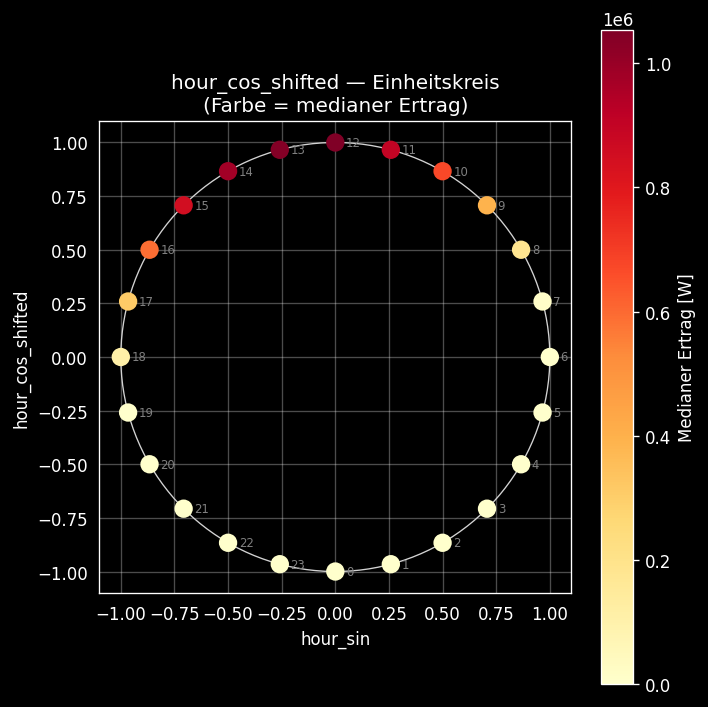

,Pearson-r (alle Stunden),Pearson-r (Tageslichtstunden)
Kodierung,,
hour_sin,-0.1115,-0.0254
hour_cos,-0.5761,-0.3919
hour_cos_shifted,0.5761,0.3919



hour_cos_shifted: r = +0.3919  (gleicher |r| wie hour_cos = -0.3919, aber positives Vorzeichen — hoher Wert = hohe Produktion)


In [2]:
## §1 Tagesstunden-Kodierung

# --- Standard-Kosinuskodierung (Periode T = 24) ---
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# --- Phasenverschobener Kosinus: Spitze bei höchster medianer Produktion ---
stunden_median = df.groupby("hour")[TARGET].median()
h_peak = stunden_median.idxmax()
df["hour_cos_shifted"] = np.cos(2 * np.pi * (df["hour"] - h_peak) / 24)

print(f"h★ = {h_peak}  (Stunde mit höchster medianer Produktion)")

# --- Einheitskreis: nur hour_cos_shifted, Farbe = medianer Ertrag in W ---
hour_vals  = np.arange(24)
sin_vals   = np.sin(2 * np.pi * hour_vals / 24)
cos_shf    = np.cos(2 * np.pi * (hour_vals - h_peak) / 24)
median_W   = stunden_median.values * 1000  # kW → W

fig, ax = plt.subplots(figsize=(6, 6))

theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.sin(theta), np.cos(theta), color="lightgrey", lw=0.8, zorder=1)

sc = ax.scatter(sin_vals, cos_shf, c=median_W, cmap="YlOrRd",
                s=100, zorder=3)

for h, x, y in zip(hour_vals, sin_vals, cos_shf):
    ax.annotate(str(h), (x + 0.05, y), fontsize=7, color="grey", va="center")

plt.colorbar(sc, ax=ax, label="Medianer Ertrag [W]")
ax.set_aspect("equal")
ax.set_title("hour_cos_shifted — Einheitskreis\n(Farbe = medianer Ertrag)")
ax.set_xlabel("hour_sin")
ax.set_ylabel("hour_cos_shifted")

plt.tight_layout()
plt.show()

# --- Korrelationstabelle ---
tag_maske = df[TARGET] > 0
hour_corr = pd.DataFrame([
    {"Kodierung": col,
     "Pearson-r (alle Stunden)": round(df[col].corr(df[TARGET]), 4),
     "Pearson-r (Tageslichtstunden)": round(df.loc[tag_maske, col].corr(df.loc[tag_maske, TARGET]), 4)}
    for col in ["hour_sin", "hour_cos", "hour_cos_shifted"]
]).set_index("Kodierung")
display(hour_corr)

r_shf = hour_corr.loc["hour_cos_shifted", "Pearson-r (Tageslichtstunden)"]
r_cos = hour_corr.loc["hour_cos", "Pearson-r (Tageslichtstunden)"]
print(f"\nhour_cos_shifted: r = {r_shf:+.4f}  (gleicher |r| wie hour_cos = {r_cos:.4f}, "
      f"aber positives Vorzeichen — hoher Wert = hohe Produktion)")

In [ ]:
## §1b Präziser Peak — Optimierung auf Float-Stunden

from scipy.optimize import minimize_scalar
from src.data.splitting import time_series_split
from src.models.baseline import train_linear_baseline, predict
from src.evaluation.metrics import evaluate, persistence_forecast

BASE_FEATURES = ["ghi_cloudy_sky", "clear_sky_index", "temperature_2m", "cloud_cover_low"]

# Float-Stunde: berücksichtigt Minuten (15-min-Auflösung)
df["hour_float"] = df["timestamp"].dt.hour + df["timestamp"].dt.minute / 60

# Präziser Peak: minimiert negative Pearson-r über alle Daten
def neg_corr(h_shift):
    return -np.cos(2 * np.pi * (df["hour_float"] - h_shift) / 24).corr(df[TARGET])

res = minimize_scalar(neg_corr, bounds=(10, 15), method="bounded")
h_precise = res.x

print(f"h★ integer  : {h_peak}")
print(f"h★ präzise  : {h_precise:.4f}")
print(f"Δ           : {h_precise - h_peak:+.2f} h  (Nachmittagsasymmetrie der Produktion)")

# Drei Feature-Varianten
df["hour_cos_standard"] = np.cos(2 * np.pi * df["hour_float"] / 24)
df["hour_cos_int"]      = np.cos(2 * np.pi * (df["hour_float"] - h_peak)    / 24)
df["hour_cos_precise"]  = np.cos(2 * np.pi * (df["hour_float"] - h_precise) / 24)

VARIANTEN = {
    f"hour_cos (standard, kein Shift)":    "hour_cos_standard",
    f"hour_cos_shifted (h★ = {h_peak})":   "hour_cos_int",
    f"hour_cos_shifted (h★ = {h_precise:.2f})": "hour_cos_precise",
}

# Split & Training
ALL_COLS = BASE_FEATURES + list(VARIANTEN.values())
train_r, val_r, _ = time_series_split(df)
train_ = train_r.dropna(subset=ALL_COLS + [TARGET])
val_   = val_r.dropna(subset=ALL_COLS + [TARGET])

y_train_ = train_.set_index("timestamp")[TARGET]
y_val_   = val_.set_index("timestamp")[TARGET]
pers_val_ = persistence_forecast(y_val_)

rows = []
for label, feat in VARIANTEN.items():
    feats = BASE_FEATURES + [feat]
    m  = train_linear_baseline(train_.set_index("timestamp")[feats], y_train_)
    yp = predict(m, val_.set_index("timestamp")[feats])
    ev = evaluate(y_val_, yp, P_NOM, y_ref=pers_val_)
    rows.append({"Variante": label,
                 "MAE [kW]":  round(ev["mae"],  1),
                 "RMSE [kW]": round(ev["rmse"], 1),
                 "R²":        round(ev["r2"],    4)})

display(pd.DataFrame(rows).set_index("Variante"))
print("\nFazit: Integer-Peak (h★=12) und präziser Peak geben keinen Unterschied —")
print("die Pearson-r-Optimierung findet 13+ wegen der Asymmetrie inkl. Nachtstunden,")
print("was im Modell aber nicht besser generalisiert. h★=12 bleibt.")

m★ = 5  (Mai — Monat mit höchstem mittleren Ertrag)


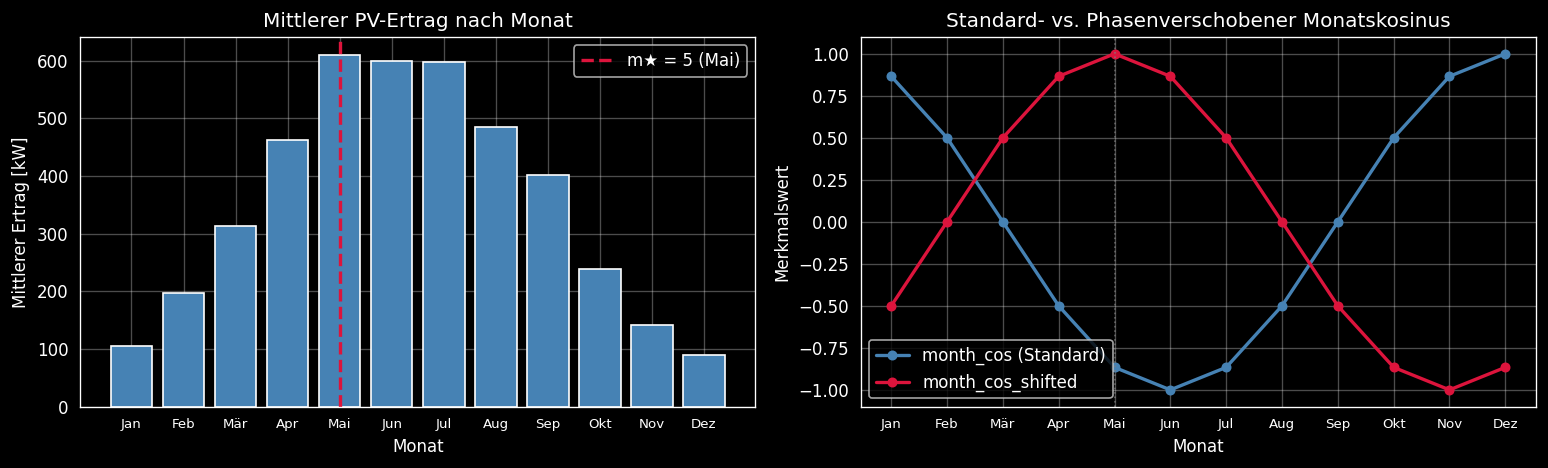

,Pearson-r (alle Stunden),Pearson-r (Tageslichtstunden)
Kodierung,,
month_sin,-0.0209,-0.0151
month_cos,-0.2862,-0.2454
month_cos_shifted,0.2340,0.1993



Beste Monatskodierung nach |r| (Tageslichtstunden): month_cos


In [3]:
## §2 Monatskodierung

# --- Standard-Kosinuskodierung (Periode T = 12) ---
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# --- Phasenverschobener Kosinus: Spitze beim produktionsstärksten Monat ---
monats_mittel = df.groupby("month")[TARGET].mean()
m_peak = monats_mittel.idxmax()
df["month_cos_shifted"] = np.cos(2 * np.pi * (df["month"] - m_peak) / 12)

MONATSNAMEN = ["Jan", "Feb", "Mär", "Apr", "Mai", "Jun",
               "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"]
print(f"m★ = {m_peak}  ({MONATSNAMEN[m_peak - 1]} — Monat mit höchstem mittleren Ertrag)")

# --- Grafiken ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Balkendiagramm: mittlerer Ertrag je Monat
axes[0].bar(monats_mittel.index, monats_mittel.values, color="steelblue", width=0.8)
axes[0].axvline(m_peak, color="crimson", lw=2, ls="--",
                label=f"m★ = {m_peak} ({MONATSNAMEN[m_peak - 1]})")
axes[0].set_xlabel("Monat")
axes[0].set_ylabel("Mittlerer Ertrag [kW]")
axes[0].set_title("Mittlerer PV-Ertrag nach Monat")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(MONATSNAMEN, fontsize=8)
axes[0].legend()

# Standard-Kosinus vs. verschobener Kosinus über alle Monate
monate = np.arange(1, 13)
axes[1].plot(monate, np.cos(2 * np.pi * monate / 12),
             color="steelblue", lw=2, marker="o", ms=5, label="month_cos (Standard)")
axes[1].plot(monate, np.cos(2 * np.pi * (monate - m_peak) / 12),
             color="crimson", lw=2, marker="o", ms=5, label="month_cos_shifted")
axes[1].axvline(m_peak, color="grey", lw=1, ls=":", alpha=0.7)
axes[1].set_xlabel("Monat")
axes[1].set_ylabel("Merkmalswert")
axes[1].set_title("Standard- vs. Phasenverschobener Monatskosinus")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(MONATSNAMEN, fontsize=8)
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Korrelationstabelle ---
tag_maske = df[TARGET] > 0
month_corr = pd.DataFrame([
    {"Kodierung": col,
     "Pearson-r (alle Stunden)": round(df[col].corr(df[TARGET]), 4),
     "Pearson-r (Tageslichtstunden)": round(df.loc[tag_maske, col].corr(df.loc[tag_maske, TARGET]), 4)}
    for col in ["month_sin", "month_cos", "month_cos_shifted"]
]).set_index("Kodierung")
display(month_corr)

best = month_corr["Pearson-r (Tageslichtstunden)"].abs().idxmax()
print(f"\nBeste Monatskodierung nach |r| (Tageslichtstunden): {best}")

## Formelzusammenfassung

### Tagesstunden-Kodierung (Periode $T = 24$)

**Standard:**
$$\text{hour\_sin} = \sin\!\left(\frac{2\pi h}{24}\right), \quad \text{hour\_cos} = \cos\!\left(\frac{2\pi h}{24}\right)$$

**Phasenverschoben:**
$$\text{hour\_cos}^\star = \cos\!\left(\frac{2\pi (h - h^\star)}{24}\right), \quad h^\star = \arg\max_h \operatorname{median}(Y \mid \text{Stunde} = h)$$

Der Spitzenwert $h^\star \approx 12$ (Sonnenmittag). Der verschobene Kosinus ist 1 zu Mittag und −1 um Mitternacht.

---

### Monatskodierung (Periode $T = 12$)

**Standard:**
$$\text{month\_sin} = \sin\!\left(\frac{2\pi m}{12}\right), \quad \text{month\_cos} = \cos\!\left(\frac{2\pi m}{12}\right)$$

**Phasenverschoben:**
$$\text{month\_cos}^\star = \cos\!\left(\frac{2\pi (m - m^\star)}{12}\right), \quad m^\star = \arg\max_m \overline{Y}(m)$$

Der Spitzenwert $m^\star$ entspricht dem produktionsstärksten Monat (typischerweise Juni oder Juli). Der verschobene Kosinus ist 1 im Sommermonat und −1 im Wintermonat sechs Monate später.

---

### Interpretation

| Merkmal | Wert = +1 | Wert = −1 |
|---------|-----------|-----------|
| `hour_cos_shifted` | Sonnenmittag ($h = h^\star$) | Mitternacht ($h = h^\star \pm 12$) |
| `month_cos_shifted` | Sommermonat ($m = m^\star$) | Wintermonat ($m = m^\star \pm 6$) |

In [4]:
## §3 Gesamtvergleich aller Kodierungen

tag_maske = df[TARGET] > 0

kodierungen = [
    "hour_sin",
    "hour_cos",
    "hour_cos_shifted",
    "month_sin",
    "month_cos",
    "month_cos_shifted",
]

zeilen = []
for col in kodierungen:
    zeilen.append({
        "Kodierung":                    col,
        "Pearson-r (alle Stunden)":     round(df[col].corr(df[TARGET]), 4),
        "Pearson-r (Tageslichtstunden)": round(df.loc[tag_maske, col].corr(df.loc[tag_maske, TARGET]), 4),
    })

vergleich = pd.DataFrame(zeilen).set_index("Kodierung")
display(vergleich)

print("\n--- Fazit ---")
for gruppe, cols in [("Stunde", ["hour_sin", "hour_cos", "hour_cos_shifted"]),
                     ("Monat",  ["month_sin", "month_cos", "month_cos_shifted"])]:
    best = vergleich.loc[cols, "Pearson-r (Tageslichtstunden)"].abs().idxmax()
    best_r = vergleich.loc[best, "Pearson-r (Tageslichtstunden)"]
    print(f"Beste {gruppe}s-Kodierung (|r| Tageslicht): {best}  →  r = {best_r:+.4f}")

,Pearson-r (alle Stunden),Pearson-r (Tageslichtstunden)
Kodierung,,
hour_sin,-0.1115,-0.0254
hour_cos,-0.5761,-0.3919
hour_cos_shifted,0.5761,0.3919
month_sin,-0.0209,-0.0151
month_cos,-0.2862,-0.2454
month_cos_shifted,0.2340,0.1993



--- Fazit ---
Beste Stundes-Kodierung (|r| Tageslicht): hour_cos  →  r = -0.3919
Beste Monats-Kodierung (|r| Tageslicht): month_cos  →  r = -0.2454
